In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LinearRegression

# Exploratory Data Analysis
## French Motor Third-Party Liability Dataset

This notebook explores the French MTPL dataset to understand the data before modelling. The analysis is split into two parts.

- **Part 1 — Severity:** Distribution and features of claim amounts (26k claims)
- **Part 2 — Frequency:** Which policies result in a claim (679k policies)

Both parts feed into separate models that are later combined to estimate a pure premium.

In [41]:
# Fetching the severity dataset
print('Fetching freMTPL2sev from OpenML...')
data = fetch_openml(name='freMTPL2sev', version=1, as_frame=True)
df = data.frame

# df.to_csv('../data/freMTPL2sev.csv', index=False)
# print(f'Saved. Shape: {df.shape}')
# df.head()

# Downloading the frequency dataset.
data_freq = fetch_openml(name='freMTPL2freq', version=1, as_frame=True)                                               
df_freq = data_freq.frame
                                                                                                                    
# df_freq.to_csv('../data/freMTPL2freq.csv', index=False)
# print(f'Frequency dataset shape: {df_freq.shape}')                                                                    
# df_freq.head()  

Fetching freMTPL2sev from OpenML...


In [42]:
# Rename severity column for clarity                                                              
df_sev = df  # the 26k claims dataset you already loaded                                       

# Join on IDpol — left join keeps all freq policies, NaN ClaimAmount = no claim 
df_merged = df_freq.merge(df_sev, on='IDpol', how='left')

# Policies with at least one claim
df_claims = df_merged[df_merged['ClaimAmount'].notna()].copy()

# Computing the 99th percentile.
p99 = df_claims['ClaimAmount'].quantile(0.99)
print(f"99th percentile: {p99:,.2f}")
print(f"Claims above it: {(df_claims['ClaimAmount'] > p99).sum()} ({(df_claims['ClaimAmount'] > p99).mean():.1%})")

# Capping claims above the 99th percentile to the 99th percentile value
df_claims['ClaimAmount'] = df_claims['ClaimAmount'].clip(upper=p99)                                                   
print(f"Max after capping: {df_claims['ClaimAmount'].max():,.2f}")

print(f'All policies:         {len(df_merged):,}')
print(f'Policies with claims: {len(df_claims):,}')
print(f'Claim rate:           {len(df_claims)/len(df_merged):.1%}')
df_claims.head()

99th percentile: 16,451.22
Claims above it: 265 (1.0%)
Max after capping: 16,451.22
All policies:         679,513
Policies with claims: 26,444
Claim rate:           3.9%


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount
66,139.0,1,0.75,F,7,1,61,50,B12,'Regular',27000,R11,303.00
93,190.0,1,0.14,B,12,5,50,60,B12,'Diesel',56,R25,1981.84
199,414.0,1,0.14,E,4,0,36,85,B12,'Regular',4792,R11,1456.55
205,424.0,2,0.62,F,10,0,51,100,B12,'Regular',27000,R11,989.64
206,424.0,2,0.62,F,10,0,51,100,B12,'Regular',27000,R11,9844.36


***
## Part 1. Severity Analysis

Dataset. 26,439 claims (policies where at least one claim was made)

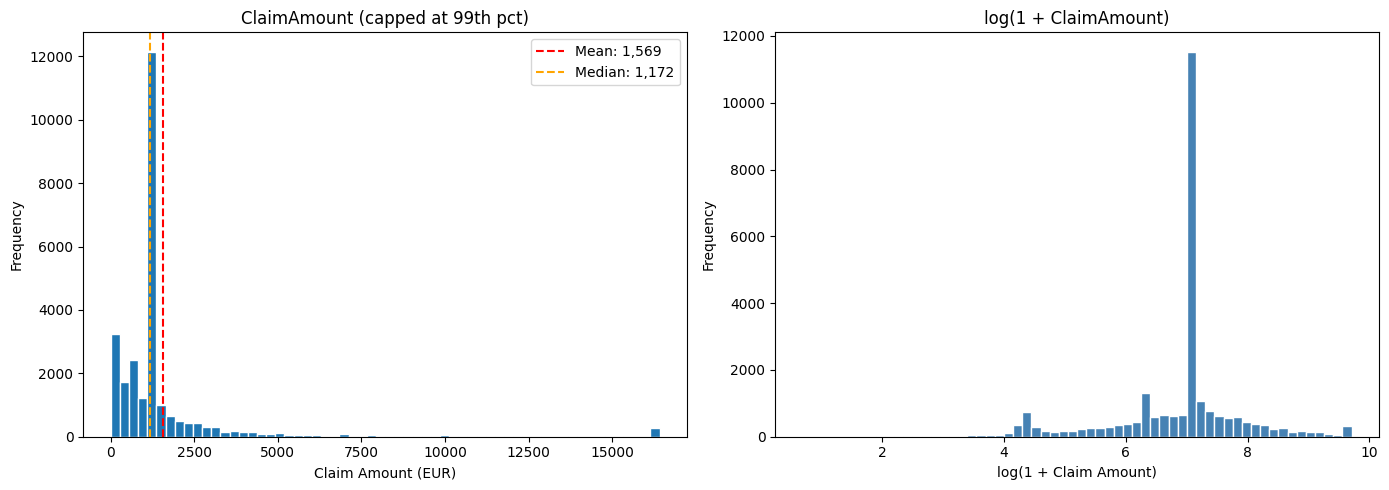

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution capped at 99th percentile
cap = df_claims['ClaimAmount'].quantile(0.99)
axes[0].hist(df_claims['ClaimAmount'].clip(upper=cap), bins=60, edgecolor='white')
axes[0].set_title('ClaimAmount (capped at 99th pct)')
axes[0].set_xlabel('Claim Amount (EUR)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_claims['ClaimAmount'].mean(), color='red', linestyle='--', label=f"Mean: {df_claims['ClaimAmount'].mean():,.0f}")
axes[0].axvline(df_claims['ClaimAmount'].median(), color='orange', linestyle='--', label=f"Median: {df_claims['ClaimAmount'].median():,.0f}")
axes[0].legend()

# Log-transformed
axes[1].hist(np.log1p(df_claims['ClaimAmount']), bins=60, edgecolor='white', color='steelblue')
axes[1].set_title('log(1 + ClaimAmount)')
axes[1].set_xlabel('log(1 + Claim Amount)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../results/01_claim_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Claim Amount Distribution

ClaimAmount is heavily right-skewed (mean 1,569 EUR vs median 1,172 EUR), with extreme outliers up to 4M EUR. The top 1% of claims (265 records) were capped at the 99th percentile (16,451 EUR).

The log-transformed distribution is approximately normal, which motivates two modelling choices.

1. Using a **Gamma GLM with log-link** rather than ordinary linear regression
2. Log-transforming the target when training the neural network

Many claims cluster at round amounts (1,204 EUR, 1,128 EUR, 1,172 EUR), likely standardised repair tariffs rather than individually assessed claims. This is a known characteristic of this dataset.

In [44]:
print(df_claims['ClaimAmount'].describe())                                                                            
print(f"\nTop 5 largest claims:")
print(df_claims['ClaimAmount'].nlargest(5).values)

count    26444.000000
mean      1569.161516
std       2224.267430
min          1.000000
25%        685.992500
50%       1172.000000
75%       1212.385000
max      16451.224000
Name: ClaimAmount, dtype: float64

Top 5 largest claims:
[16451.224 16451.224 16451.224 16451.224 16451.224]


In [45]:
df_claims.describe(include='all') 

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount
count,2.644400e+04,26444.000000,26444.000000,26444,26444.000000,26444.000000,26444.000000,26444.000000,26444,26444,26444.000000,26444,26444.000000
unique,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN,11,2,NaN,22,NaN
top,NaN,NaN,NaN,C,NaN,NaN,NaN,NaN,B1,'Diesel',NaN,R24,NaN
freq,NaN,NaN,NaN,7093,NaN,NaN,NaN,NaN,6898,13450,NaN,6475,NaN
mean,2.280004e+06,1.139427,0.691791,NaN,6.464415,7.355090,45.121502,65.231054,NaN,NaN,2015.302942,NaN,1569.161516
std,1.583004e+06,0.617563,0.313213,NaN,2.017260,5.165475,14.694677,20.143480,NaN,NaN,4162.639153,NaN,2224.267430
min,1.390000e+02,1.000000,0.002740,NaN,4.000000,0.000000,18.000000,50.000000,NaN,NaN,2.000000,NaN,1.000000
25%,1.086381e+06,1.000000,0.450000,NaN,5.000000,3.000000,34.000000,50.000000,NaN,NaN,115.000000,NaN,685.992500
50%,2.133756e+06,1.000000,0.760000,NaN,6.000000,7.000000,45.000000,55.000000,NaN,NaN,524.500000,NaN,1172.000000
75%,3.183953e+06,1.000000,1.000000,NaN,7.000000,11.000000,54.000000,76.000000,NaN,NaN,2252.000000,NaN,1212.385000


In [46]:
print(f"VehAge == 99:  {(df_claims['VehAge'] == 99).sum()}")
print(f"DrivAge == 99: {(df_claims['DrivAge'] == 99).sum()}")

# Dropping claims where vehicle age is 99 and driver's age is 99.
df_claims = df_claims[(df_claims['VehAge'] != 99) & (df_claims['DrivAge'] != 99)]                                     
print(f"Remaining records: {len(df_claims):,}")

VehAge == 99:  1
DrivAge == 99: 4
Remaining records: 26,439


## Data Quality

5 records with placeholder values (VehAge or DrivAge = 99) were removed, leaving **26,439 clean records**. No missing values were found elsewhere in the dataset.

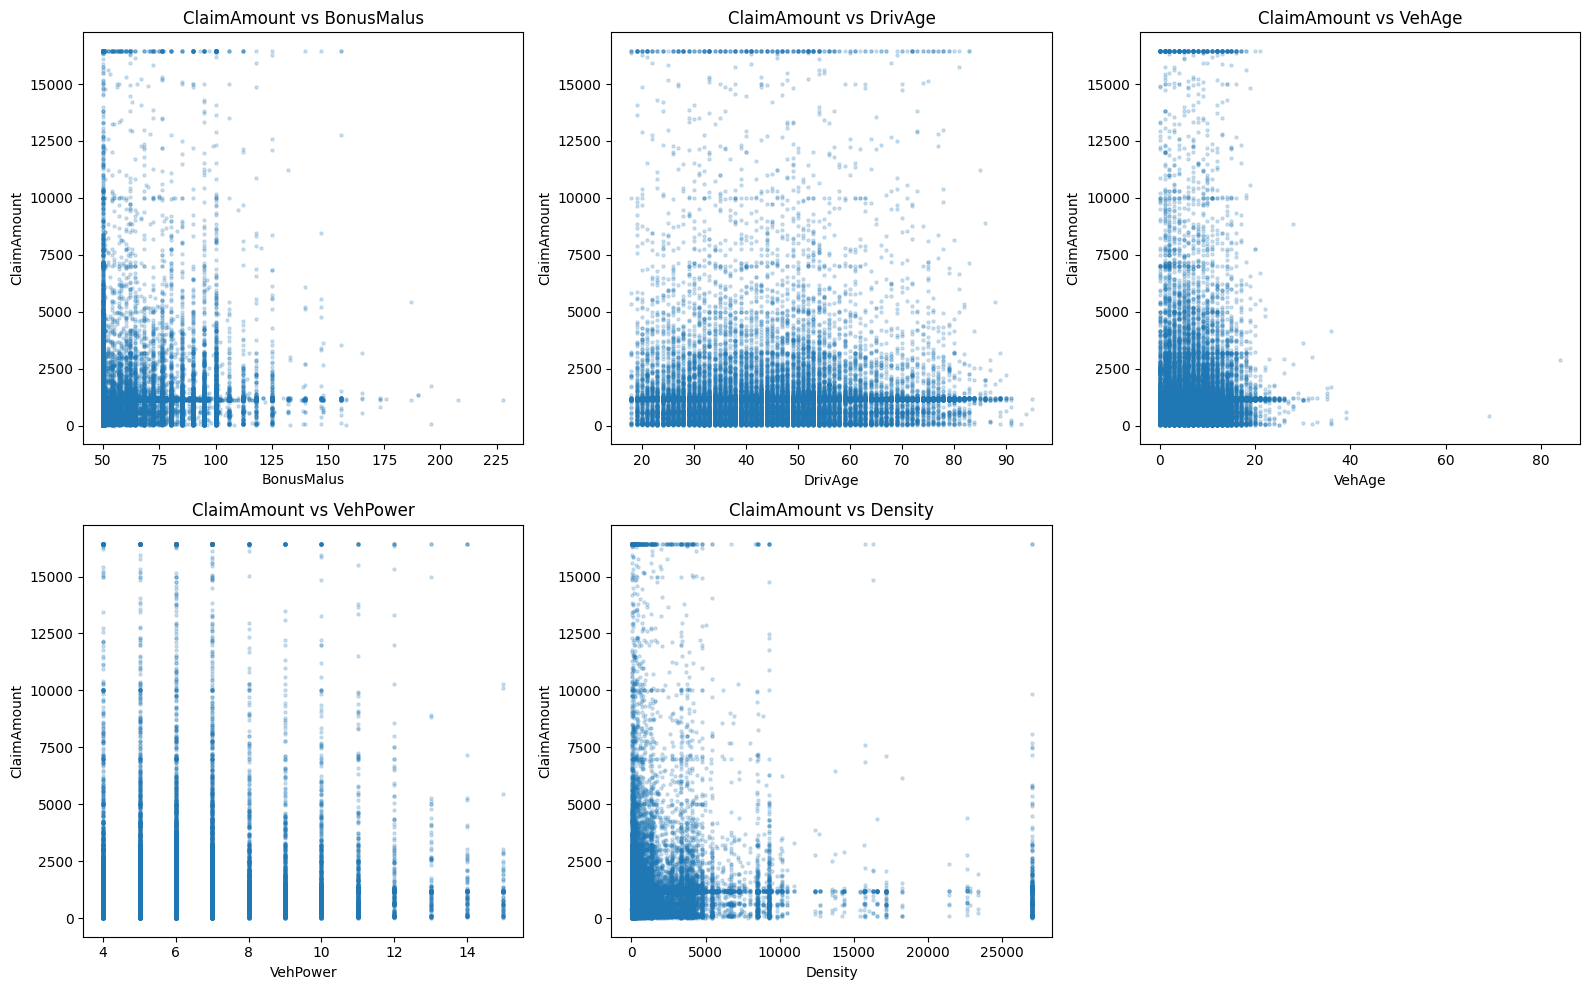

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))                                                                      
axes = axes.flatten()                                                                                                 
                                                                                                                    
num_features = ['BonusMalus', 'DrivAge', 'VehAge', 'VehPower', 'Density']                                             
                
for i, col in enumerate(num_features):                                                                                
    axes[i].scatter(df_claims[col], df_claims['ClaimAmount'], alpha=0.2, s=5)
    axes[i].set_xlabel(col)                                                                                           
    axes[i].set_ylabel('ClaimAmount')                                                                                 
    axes[i].set_title(f'ClaimAmount vs {col}')
                                                                                                                    
axes[5].set_visible(False)                                                                                            
plt.tight_layout()
plt.savefig('../results/02_feature_vs_claim.png', dpi=150, bbox_inches='tight')                                       
plt.show()

/Users/danielpark/Documents/insurance_claims_severity/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/danielpark/Documents/insurance_claims_severity/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/danielpark/Documents/insurance_claims_severity/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/danielpark/Documents/insurance_claims_severity/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/danielpark/Documents/insurance_cl

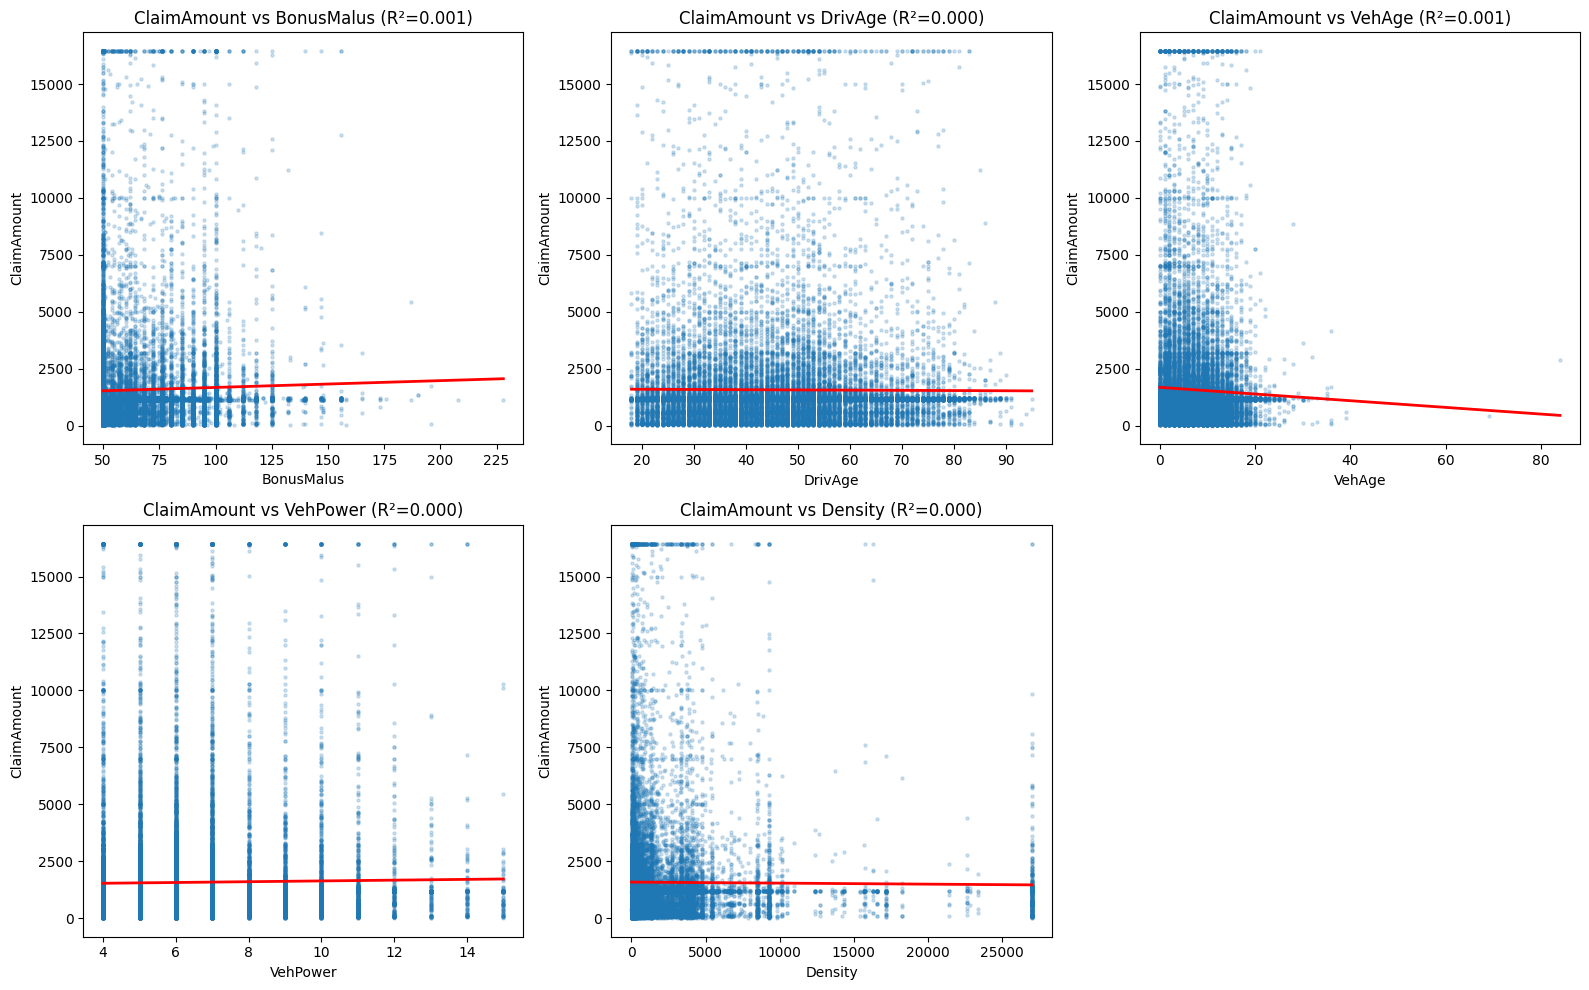

In [48]:
num_features = ['BonusMalus', 'DrivAge', 'VehAge', 'VehPower', 'Density']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    x = df_claims[[col]]
    y = df_claims['ClaimAmount']

    model = LinearRegression().fit(x, y)
    x_line = np.linspace(x[col].min(), x[col].max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)

    axes[i].scatter(df_claims[col], y, alpha=0.2, s=5)
    axes[i].plot(x_line, y_line, color='red', linewidth=2)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('ClaimAmount')
    axes[i].set_title(f'ClaimAmount vs {col} (R²={model.score(x, y):.3f})')

axes[5].set_visible(False)
plt.tight_layout()
plt.savefig('../results/02_feature_vs_claim.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature vs Severity: Key Insight

All individual features show near-zero R² against ClaimAmount. This is expected and is a fundamental property of insurance severity modelling — these features predict **whether** a claim happens (frequency), not **how much** it costs (severity).

For example, BonusMalus (claims history score) predicts that a risky driver will crash more often, but when they do crash, the repair bill isn't systematically larger than a careful driver's.

The signal in severity modelling comes from **combining features together**, which is what the GLM, XGBoost, and neural network will do in the following notebooks.

In [49]:
df_merged['HasClaim'] = (df_merged['ClaimAmount'].notna()).astype(int)                                                
                                                                                                                    
print('--- Claim Frequency Summary ---')                                                                              
print(f"Total policies:       {len(df_merged):,}")                                                                    
print(f"Policies with claims: {df_merged['HasClaim'].sum():,}")                                                       
print(f"Overall claim rate:   {df_merged['HasClaim'].mean():.3%}")
print()                                                                                                               
print('ClaimNb distribution (among policies with claims):')
print(df_merged[df_merged['HasClaim']==1]['ClaimNb'].value_counts().sort_index())

--- Claim Frequency Summary ---
Total policies:       679,513
Policies with claims: 26,444
Overall claim rate:   3.892%

ClaimNb distribution (among policies with claims):
ClaimNb
1     23570
2      2597
3       186
4        20
5        10
6         6
8         8
9         9
11       22
16       16
Name: count, dtype: int64


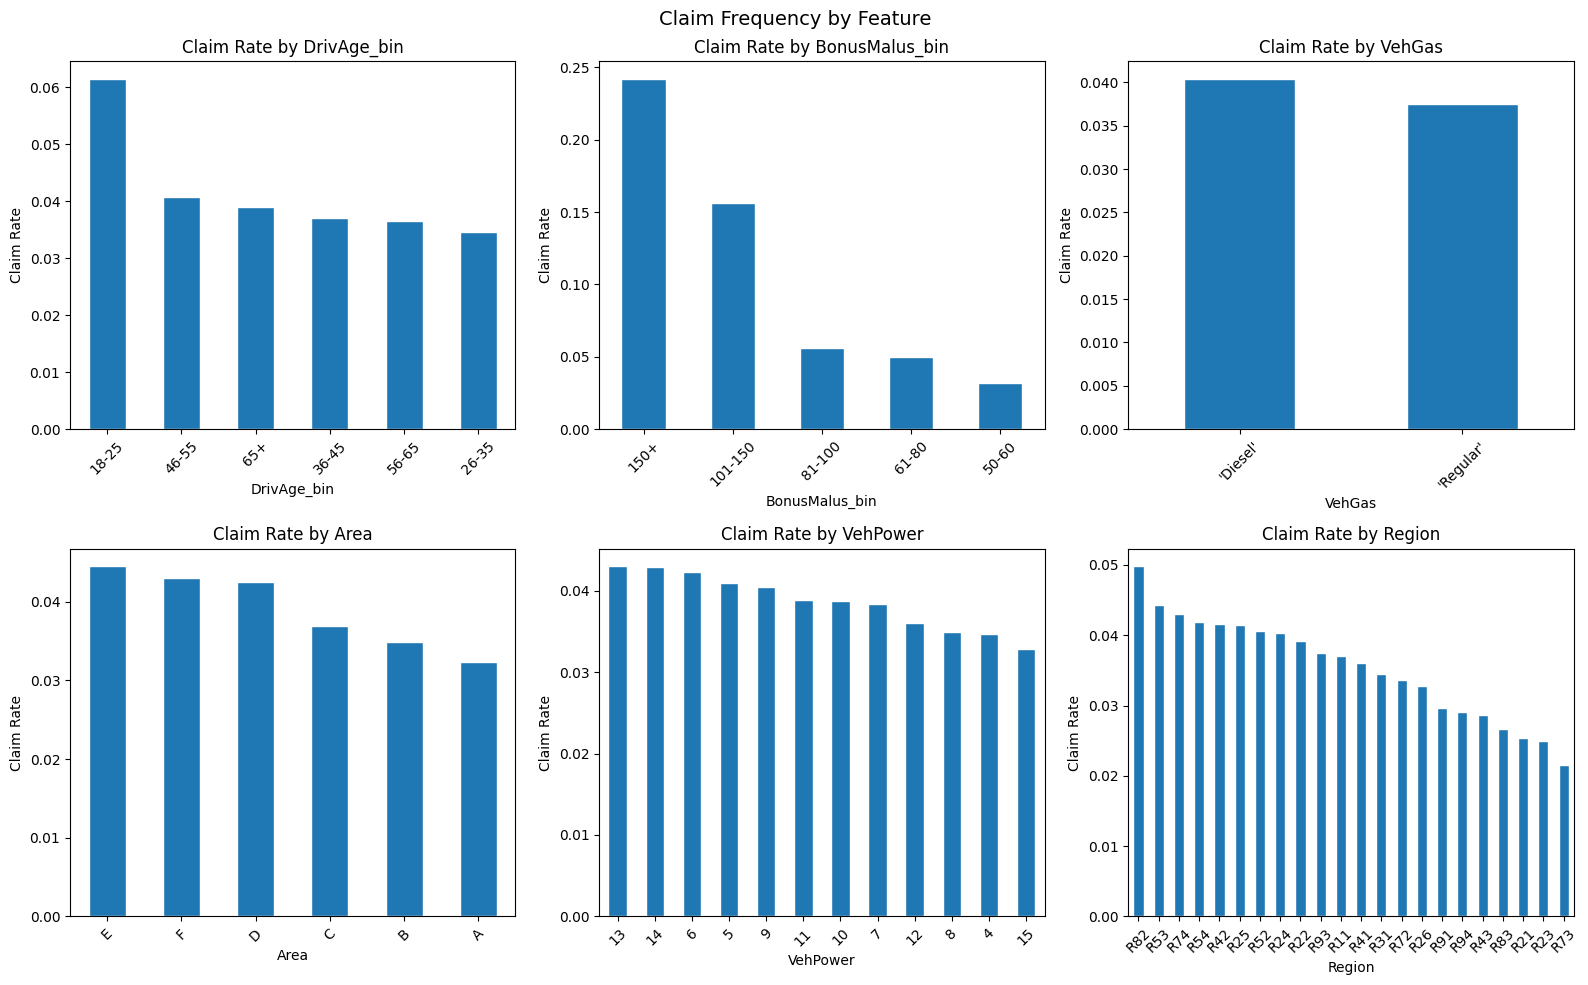

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

df_merged['DrivAge_bin'] = pd.cut(df_merged['DrivAge'], bins=[17,25,35,45,55,65,100], labels=['18-25','26-35','36-45','46-55','56-65','65+'])
df_merged['BonusMalus_bin'] = pd.cut(df_merged['BonusMalus'], bins=[49,60,80,100,150,230], labels=['50-60','61-80','81-100','101-150','150+'])

cat_features = ['DrivAge_bin', 'BonusMalus_bin', 'VehGas', 'Area', 'VehPower', 'Region']

for i, col in enumerate(cat_features):
    rates = df_merged.groupby(col)['HasClaim'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=axes[i], edgecolor='white')
    axes[i].set_title(f'Claim Rate by {col}')
    axes[i].set_ylabel('Claim Rate')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Claim Frequency by Feature', fontsize=14)
plt.tight_layout()
plt.savefig('../results/03_claim_frequency_by_feature.png', dpi=150, bbox_inches='tight')
plt.show()

***
## Part 2. Frequency Analysis

Dataset. 679,513 policies (the full dataset including policies with no claims)

In [51]:
# Save cleaned datasets for modelling notebooks
df_claims.to_csv('../data/claims_cleaned.csv', index=False)
df_merged.to_csv('../data/policies_cleaned.csv', index=False)
print(f'Severity dataset saved: {df_claims.shape}')
print(f'Frequency dataset saved: {df_merged.shape}')

Severity dataset saved: (26439, 13)
Frequency dataset saved: (679513, 16)


## Claim Frequency Findings

Unlike severity, frequency shows clear and intuitive relationships with individual features.

- **BonusMalus** — strongest predictor by far. Drivers with a score of 150+ claim at 24% vs 3% for clean-record drivers (50–60). This is exactly what the score is designed to measure.
- **DrivAge** — young drivers (18–25) claim at 6%, dropping steadily with age. Classic insurance pattern reflecting inexperience.
- **Area** — areas E, F, D have higher claim rates (~4.5%) than A and B (~3.2%), consistent with higher-density/traffic environments.
- **VehPower** — higher power vehicles tend to claim more frequently.
- **Region** — meaningful geographic variation (R82 ~5%, R73 ~2%), reflecting differences in road conditions and traffic density.
- **VehGas** — Diesel slightly higher than Regular (4.0% vs 3.8%).

These features predict **whether** a claim happens. In the modelling notebooks we build a Poisson GLM to quantify these effects formally, then combine with the severity model to estimate a pure premium.